# 시계열 사전과제
## 시계열 데이터란?

### 1. 시계열 데이터 정의
* 시간의 흐름에 따라 수집된 데이터 (시퀀스 데이터)
* 단변량 시계열: 시간에 따라 연속적으로 측정된 단일 변수 시계열 데이터
* 다변량 시계열: 둘 이상의 변수로 이루어진 시계열 데이터

### 2. 시계열 데이터 특징
1. 시간의존성: 순서를 바꾸면 의미가 달라지며, 시점 간 상관관계를 고려해야함
2. 계절성: 일정주기에 따라 반복적으로 나타나는 데이터의 변동 / 추세: 시간에 흐름에 따라 나타나는 장기적인 증, 감 경향
3. 자기상관성: 이전 시점 값이 이후 시점 값에 영향을 미치는 것. 일정 패턴이나 반복이 존재하는 것

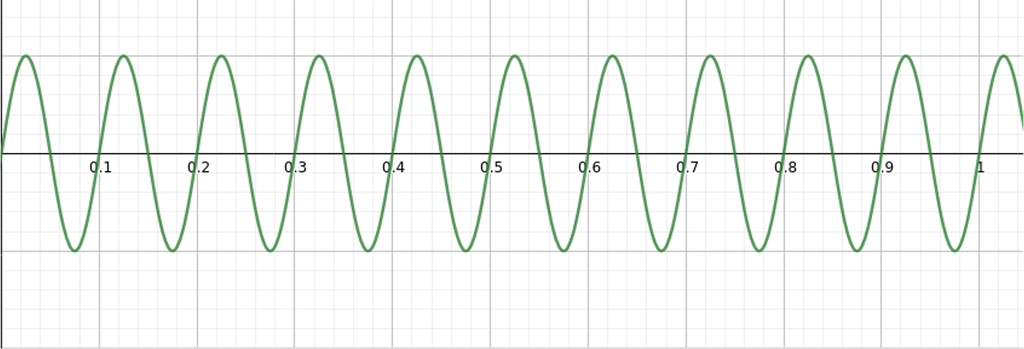

> 자기 상관성이 높은 데이터 예시

#### 자기상관성 있는 데이터를 일반 회귀분석 하면 안되는 이유
1. 오차항 독립성 가정 위반 -> 통계 결과 왜곡됨
2. 허위 상관관계 문제: 자기 상관성 있는 두 시계열을 OLS 회귀 돌리면 -> 잘못된 상관관계 발생할 수 있음 -> 각 시계열 변수에서 추세 제거
3. 예측의 어려움, 모델 복잡성 증가 -> 잔차가 시간에 따라 패턴을 가져서 미래값 예측 왜곡 / 단순 회귀 모델 아닌 AR, ARIMA등으로 대체 필요


### 3. 시계열 데이터 분석 요인
1. 추세 요인: 데이터 전반에 걸쳐 시간에 따라 지속적으로 증, 감하는 경항

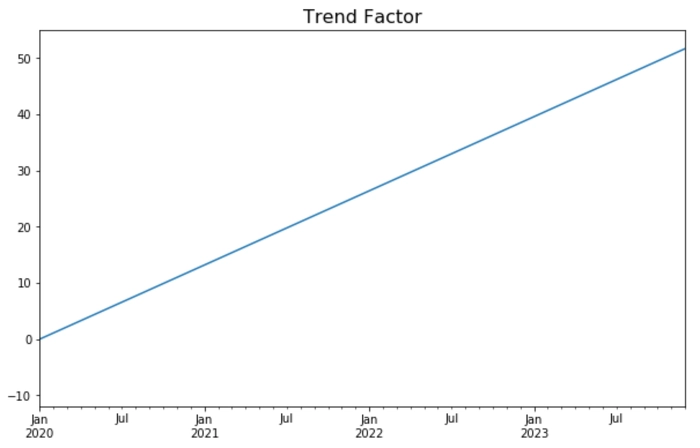

2. 계절 요인: 일정한 주기로 반복되는 패턴

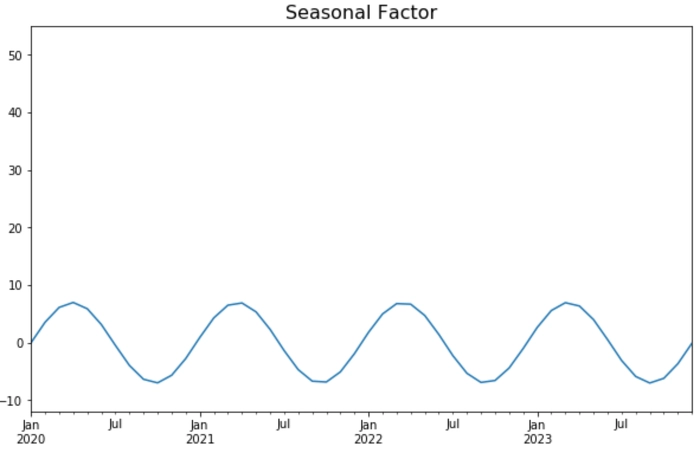

3. 순환 요인: 계절성보다 길고 불규칙한 주기로 반복되는 변동

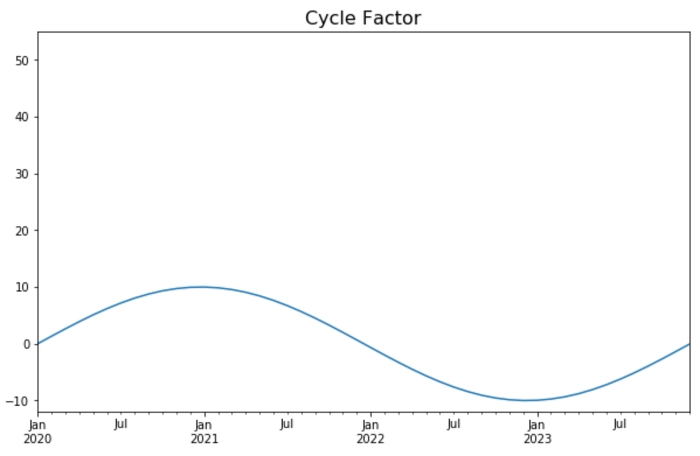

4. 불규칙 요인: 추세, 계절성, 순환성 모두 제거한 후 남은 예측 불가 변동

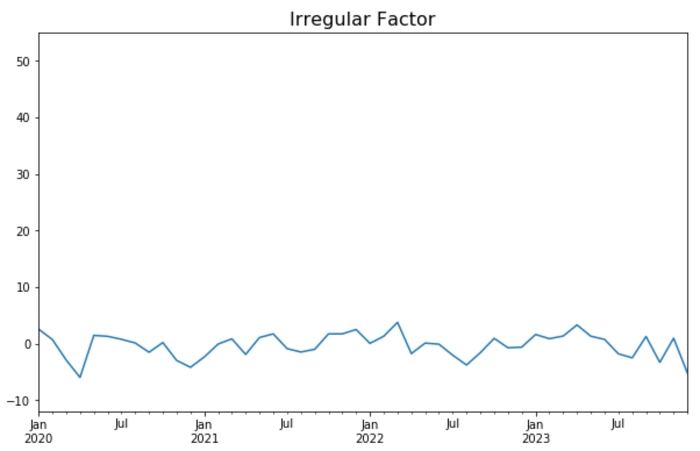

### 4. 시계열 데이터 분석 work flow
1. 데이터 전처리
2. 정상성 판단
3. 모델링 예측

## 시계열 데이터 전처리

1. 결측치 / 이상치 탐지 및 처리
   * 시계열 데이터 결측치: 특정 시점 값이 누락된 상태
   * 삭제 / 단순 대치/ 보간/ 머신러닝 기법 등 다양한 방법 존재
   * 보간법
     - 두 개 이상의 데이터 포인트 사이에서 누락된 값을 추정하는 수학적 기법
     - 보간 방법: 선형 보간법, 다항식 보간법, 스플라인 보간법, 조각별 상수 보간법
   * 시계열 데이터의 이상치: 신호에 대한 사전지식이 필요
   * 이상치 탐지 방법
     - IQR Rule-based Anomaly Detection: 주기성 없거나, 안정적 구간의 값에서 이상치 탐지 시 사용
     - Z-score: 계절성, 추세가 약하거나 값의 변동폭이 일정한 시계열에서 효과적. 구간별로 나눠서 계산 시 추세 영향 줄일 수 있다
     - STL 분해: 잔차가 특정 임계값을 초과하면 이상 탐지. 계절성이나 추세가 뚜렷한 시계열에 적합
   * 이상치 탐지 모델
     - CART(분류 및 회귀 트리): 과거 구간의 값 입력 -> 다음 시점 값 예측하고 예측 오차 기반으로 이상 판단
     - 클러스터링 기반 이상 탐지: 시계열 특징 추출 후 각 시점 벡터로 표현해 클러스터링 수행
     - 오토 인코더: 인공신경망 기반 비지도 학습 모델. LSTM 오토인코더 사용 시 시계열의 시간적 의존성도 학습 가능

2. EDA (평활화)
* 평활화: 시계열 데이터에서 노이즈 줄이고, 데이터 부드럽게 만드는 기술
* 이동평균: 시계열의 부분집합으로 평균을 구하여 평활화 효과를 얻는 방법
  - 단순 이동평균: 단순히 기간 내 모든 값 평균, 비교적 안정적인 시계열에서 사용
  - 가중 이동평균: 최근 값에 더 큰 가중치 부여, 최근 데이터가 중요한 상황에 사용
  - 지수 이동평균: 최근 데이터에 지수적으로 더 큰 가중치 부여, 최근 값에 매우 빠르게 반응해야하는 시계열에 사용

3. 요소분해
* 주어진 시계열 데이터를 개별 성분(추세성, 계절성, 순환성, 불규칙성)으로 분해하는 과정
* 분해 모형
    - 가법 모형: y_t= T_t + S_t + R_t , 모든 요소 영향이 일정할 때.
    - 승법 모형: y_t= T_t* S_t * R_t , 추세 커질수록 계절성이나 불규칙성 효과도 비례해서 커짐. 로그 변환 통해 가법 형태로 만들 수도 있음
* 분해 방법
    - seasonal_decompose(이동평균 기반 분해): 이동평균 통해 추세 추출 -> 잔여 성분에서 계절성을 분리
    - STL-LOESS 기반 분해: 이동평균 대신 LOESS를 사용. 추세와 계절성이 시간에 따라 변하는 경우에도 유연하게 포착 가능. 
      + Inner Loop(반복 수렴), Outer Loop 이중 반복 구조로 구성됨

## 정상성 판단


### 1. 정상성이란?
* 정상성: 시계열 데이터의 평균, 분산 등 통계적 특성이 시간에 따라 일정한 수준으로 유지되는 것 -> 정상 시계열 (정상성 띰) / 비정상 시계열 (정상성 안 띰)

### 2. 강한 정상성과 약한 정상성
* 강한 정상성: t가 언제든 데이터 확률분포 동일 -> 완벽, 비현실적
* 약한 정상성: t 변화에 따라 평균, 분산 일정하고 자기공분산은 시차에만 의존함 -> 실무에서 쓰이는 기준

### 3. 정상성 판단
1. 시각적으로 판단: 비정상 시계열은 추세 or 계절성 있음.
2. 통계적 검정: 단위근 검정 (과거 충격이 영구적으로 누적되는 특성. 대표적 비정상성의 원인이다.)
   * 시계열 모델의 특성방정식에서 근이 1인 경우, 해당 시계열은 단위근을 가짐 = 비정상 시계열이다
   * y=a*y_(t-1) + e_t 모델 -> a가 특성 방정식의 근이며, 절댓값이 1보다 작으면 정상 시계열 (과거 충격 희석), 절댓값이 1이면 단위근이 존재하는 비정상 시계열이다.

#### 단위근 검정
1. ADF
   * 단위근 존재 여부 검정
   * 귀무가설: 단위근이 존재한다
   * p-value가 유의수준보다 작으면 귀무가설 기각, 정상 시계열이라 판단
2. KPSS 검정
   * 시계열이 정상임을 검정
   * 귀무가설: 단위근이 존재하지 않는다
   * p-value가 유의수준모다 작으면 귀무가설 기각, 비정상 시계열이라 판단
3. 두 검정 결과 조합 해석 

| ADF | KPSS | 진단 | 다음 액션 |
| --- | --- | --- | --- |
| 정상 | 정상 | 정상 시계열 | 그대로 모델링 가능 |
| 비정상 | 비정상 | 단위근 존재(확률적 추세) | 차분 적용 |
| 비정상 | 정상 | 확정적 추세 의심 | 추세 제거 or 추세항 모델링 |

### 4. 정상성 확보 방법
1. 추세 제거: 차분한다(연이은 관측값 차이 계산) -> 누적 값을 빼주면 정상 시계열 얻기 가능 / 1차 차분: 한 번의 잔차, 2차 차분: 한 번 더 차분한 것, 역차분: 분석 끝내고 다시 이전 값을 복원
2. 계절성 제거: 계절 차분(주기 반영하여 차분함)
3. 분산 안정화: 로그변환

## 단변량 시계열 분석

### 1. 안정적 시계열 분석
1. 자기 회귀 모델(AR): 과거 자신의 데이터가 미래 값 설명해줄 것이라 가정하는 것
   * 시계열 데이터의 자기상관성 활용

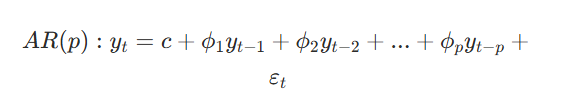

> * p차 차기 회귀 묘형.
> * 과거 p개 시점 데이터의 선형 조합을 이용해 예측

2. 이동평균 모델 (MA): 평활화와 다른 개념이다. 과거 시점의 잔차를 독립변수 삼아, 현재 값을 예측하는 모델
    * 과거의 잘못 예측한 것(오차, 충격)을 현재 시점에 반영하는 모델

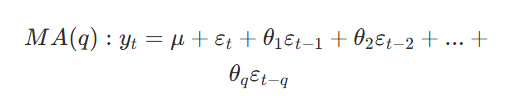

> * q차 이동 평균 모형
> * 과거 q개의 예측 오차의 선형 결합으로 예측

3. AR, MA 모델의 전제 조건
   1) 정상성 만족
    + AR모델 특성방정식의 모든 해 절댓값이 1 초과해야함
    + (잔차가 정상성을 이미 만족하므로 MA 모형도 정상성 항상 만족함)
   2) 가역성
    + MA 모델을 AR 형태로 재표현 할 수 있는지 여부.
    + 오차항도 과거값으로 표현할 수 있어야 안정적이다.
    + 마찬가지로 MA 모델의 특성방정식 모든 해의 절댓값이 1 초과여야 가역성 확보

4. ARMA 모형 : AR모형 + MA 모형
   * 조건: AR 모형의 정상성 조건 + MA 모형의 가역성 조건 둘 다 만족해야함

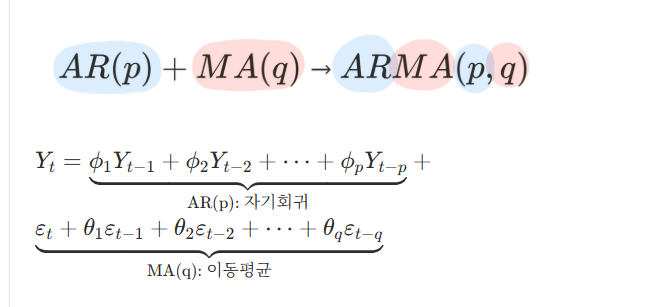

> * 과거 p개의 관측값 + 과거 q개의 오차

5. 차수 결정 방법: 자기 상관 함수
    * 두 그래프 통해 현재 값과 과거 값 관계 파악하고, 이를 통해 모델의 적절한 차수 (p,q) 결정.
    * 자기 상관 계수(ACF): ARMA(p,q) 모형에서 사용할 q개 오차 결정 방법. 두 시점 사이 상관관계 파악
    * 부분 자기 상관 계수(PACF): ARMA(p,q) 모형에서 사용할 p개 시점 결정 방법. 두 시점 사이 직접 영향만 파악
    * ACF, PACF로 차수 및 모형 결정

| **ACF 그래프** 모습 | **PACF 그래프** 모습 | **선택 모델 및 차수** |
| --- | --- | --- |
| 천천히 감소 or 진동 감소 | p+1 시점부터 0에 근접 | **AR(p) (= ARMA(p, 0)),** p = 절단 시점 |
| q+1 시점부터 0에 근접 | 천천히 감소 or 진동 감소 | **MA(q) (= ARMA(0, q)) ,** q= 절단 시점 |
| q+1 시점부터 0에 근접 | p+1 시점부터 0에 근접 | **ARMA(p, q)** |

### 2. 불안정 시계열 분석
1. 비정상 시계열 데이터 확인
2. 정상성 확보
3. 정상 시계열 만들기
4. ARMA 사용해 안정적 시계열 분석

1. ARIMA

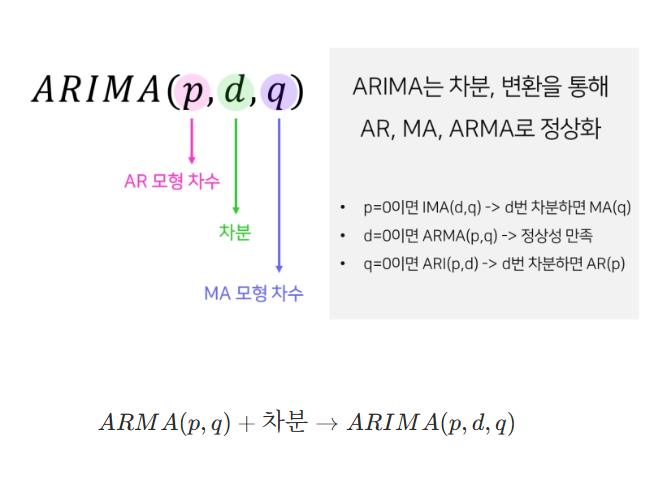

* ARIMA 모델의 특수한 경우

| 1. 백색잡음 | ARIMA(0,0,0) |
| --- | --- |
| 2. 자기회귀 | ARIMA(p,0,0) ⇔ AR(p) |
| 3. 이동평균 | ARIMA(0, 0, q) ⇔ MA(q) |
| 4. 랜덤워크 | 상수가 없는 ARIMA(0,1,0) |
| 5. 표류를 포함하는 랜덤워크 | 상수가 있는 ARIMA(0,1,0) |

2. SARIMA: 시계열 데이터 계절성 처리 가능 모델. ARIMA에 계절성 변동을 반영함

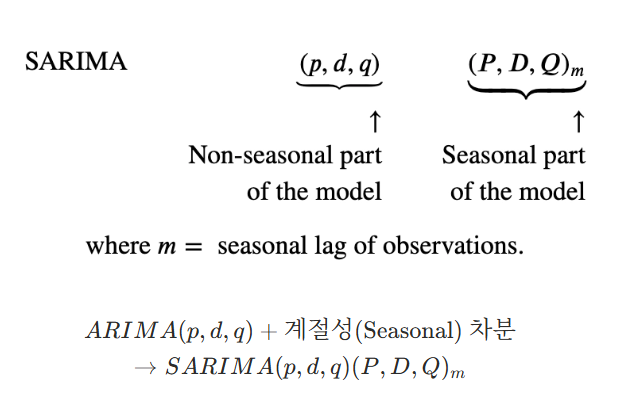

> * 하이퍼 파라미터
>    - $(p, d, q)$: 비계절 ARIMA 파라미터
>        + $p$ → AR의 차수
>        + $d$ → 차분의 정도
>        + $q$ → MA의 차수
>   - $(P, D, Q)$: 계절 ARIMA 파라미터
>        + $P$ → 계절성 AR의 차수
>        + $D$ → 계절성 차분의 정도
>        + $Q$ → 계절성 MA의 차수
>   - $m$: 계절성 주기의 길이

## 다변량 시계열 분석

* VAR(Vector Autogression)
    - 자신의 과거 값과 다른 변수들의 과거 값을 함께 사용해 미래 예측

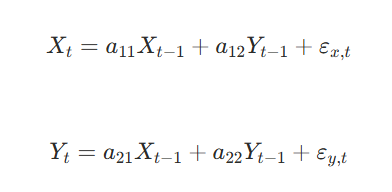

* VAR 모델 활용 분석법
    - 충격 반응 함수: 한 변수의 충격이 다른 변수에 미치는 영향 시간 흐름에 따라 분석
    - 예측 오차 분산 분해: 예측 오차가 각 변수에 얼마나 기여하나 분석

## 딥러닝 활용 시계열 분석

1. RNN, LSTM, GRU
   * 적합한 경우: 순차 패턴이 중요한 데이터
   * 부적합한 경우: 매우 긴 시계열 데이터

2. Transformer 계열
    * Informer: 장기 예측 특화
    * Automer: 주기성 포착 측화
    * TFT: 과거 데이터 + 외부 변수 섞어서 예측 가능

3. Foundation model: 거대한 데이터로 사전학습하여 다양한 문제 해결할 수 있는 범용 모델